# **Task A: Database Inspection and Cleaning**

In [1]:
# Import required libraries
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect("ecommerce_hackathon_real.db")

# Verify available tables
tables = pd.read_sql("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table';
""", conn)

tables

,name
0,customers
1,products
2,orders
3,reviews


# ***Show the shape and columns of each table.***

In [9]:
table_dict = {
    "Customers": customers,
    "Products": products,
    "Orders": orders,
    "Reviews": reviews
}

for name, df in table_dict.items():
    print(f"\n{name}")
    print(f"Shape: {df.shape}")
    print("Columns:")
    print(df.columns.tolist())


Customers
Shape: (8000, 9)
Columns:
['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']

Products
Shape: (1000, 6)
Columns:
['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']

Orders
Shape: (65000, 10)
Columns:
['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']

Reviews
Shape: (26000, 6)
Columns:
['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']


# ***Report the most important data quality issues you find.***

# Basic data quality inspection

In [10]:
for name, df in table_dict.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    
    print("Missing values:")
    print(df.isnull().sum())
    
    print("\nDuplicate rows:", df.duplicated().sum())


Customers
Missing values:
customer_id          0
customer_name        0
age                100
gender               0
city                 0
signup_date          0
membership_type      0
email                0
phone                0
dtype: int64

Duplicate rows: 0

Products
Missing values:
product_id         0
product_name       0
category           0
brand             20
unit_price         0
stock_quantity     0
dtype: int64

Duplicate rows: 0

Orders
Missing values:
order_id           0
customer_id        0
product_id         0
order_date         0
quantity           0
unit_price         0
discount           0
payment_method    55
delivery_days     40
returned           0
dtype: int64

Duplicate rows: 0

Reviews
Missing values:
review_id       0
customer_id     0
product_id      0
review_date     0
rating          0
review_text    48
dtype: int64

Duplicate rows: 0


# Duplicate IDs check

In [11]:
id_columns = {
    "Customers": "customer_id",
    "Products": "product_id",
    "Orders": "order_id",
    "Reviews": "review_id"
}

for name, df in table_dict.items():
    id_col = id_columns[name]
    print(f"{name} duplicate {id_col}s:", df[id_col].duplicated().sum())

Customers duplicate customer_ids: 0
Products duplicate product_ids: 0
Orders duplicate order_ids: 0
Reviews duplicate review_ids: 0


# Numerical values check

### Orders

In [12]:
print("Invalid quantities:")
print((orders["quantity"] <= 0).sum())

print("\nInvalid unit prices:")
print((orders["unit_price"] <= 0).sum())

print("\nInvalid delivery days:")
print((orders["delivery_days"] < 0).sum())

Invalid quantities:
45

Invalid unit prices:
35

Invalid delivery days:
0


### customers

In [13]:
print("Invalid ages:")
print(((customers["age"] < 0) | (customers["age"] > 100)).sum())

Invalid ages:
0


### Reviews

In [14]:
print("Invalid ratings:")
print(((reviews["rating"] < 1) | (reviews["rating"] > 5)).sum())

Invalid ratings:
25


### Text Category Consistency

In [15]:
print("Customer cities:")
print(customers["city"].value_counts().head(20))

print("\nProduct categories:")
print(products["category"].value_counts())

Customer cities:
city
Karachi       2149
Lahore        1461
Islamabad      798
Rawalpindi     658
Faisalabad     564
Multan         480
Peshawar       399
Hyderabad      318
Gujranwala     316
Quetta         237
Sialkot        234
Bahawalpur     159
Sargodha       157
KARACHI         10
karachi          7
 Lahore          6
lahore           5
LAHORE           4
rawalpindi       3
faisalabad       3
Name: count, dtype: int64

Product categories:
category
Fashion               218
Electronics           179
Home & Kitchen        132
Beauty                130
Groceries             100
Sports & Fitness       87
Books & Stationery     74
Baby & Kids            62
Fashion                 3
electronics             3
BEAUTY                  2
FASHION                 2
ELECTRONICS             2
Home & Kitchen          1
Baby & Kids             1
groceries               1
Electronics             1
beauty                  1
HOME & KITCHEN          1
Name: count, dtype: int64


### Date validation

In [16]:
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

reviews["review_date"] = pd.to_datetime(
    reviews["review_date"],
    errors="coerce"
)

print("Invalid customer signup dates:", customers["signup_date"].isna().sum())
print("Invalid order dates:", orders["order_date"].isna().sum())
print("Invalid review dates:", reviews["review_date"].isna().sum())

Invalid customer signup dates: 0
Invalid order dates: 30
Invalid review dates: 16


### Important missing values Summary

In [17]:
quality_summary = []

for name, df in table_dict.items():
    quality_summary.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

quality_summary = pd.DataFrame(quality_summary)

quality_summary

,Table,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,8000,9,100,0
1,Products,1000,6,20,0
2,Orders,65000,10,125,0
3,Reviews,26000,6,64,0


# ****Apply reasonable cleaning steps.****

### A. Standardize text categories. 

In [18]:
customers["city"] = customers["city"].str.strip().str.title()

products["category"] = products["category"].str.strip().str.title()
products["brand"] = products["brand"].str.strip()

### B. Missing categorical values

In [20]:
products["brand"] = products["brand"].fillna("Unknown")

orders["payment_method"] = orders["payment_method"].fillna("Unknown")

### C. Missing customer age

In [22]:
customers["age"] = customers["age"].fillna(
    customers["age"].median()
)

### D. Invalid order records

In [24]:
invalid_orders = (
    (orders["quantity"] <= 0) |
    (orders["unit_price"] <= 0)
)

print("Invalid order records:", invalid_orders.sum())

Invalid order records: 80


In [25]:
orders_clean = orders.loc[~invalid_orders].copy()

print("Original orders:", len(orders))
print("Clean orders:", len(orders_clean))

Original orders: 65000
Clean orders: 64920


### E. Invalid review ratings

In [26]:
invalid_ratings = (
    (reviews["rating"] < 1) |
    (reviews["rating"] > 5)
)

print("Invalid ratings:", invalid_ratings.sum())

Invalid ratings: 25


In [27]:
reviews_clean = reviews.loc[~invalid_ratings].copy()

print("Original reviews:", len(reviews))
print("Clean reviews:", len(reviews_clean))

Original reviews: 26000
Clean reviews: 25975


In [29]:
reviews_clean = reviews_clean.dropna(subset=["review_text"]).copy()

### F. Invalid dates


In [28]:
print("Invalid order dates:", orders_clean["order_date"].isna().sum())
print("Invalid review dates:", reviews_clean["review_date"].isna().sum())

Invalid order dates: 30
Invalid review dates: 16


In [30]:
orders_clean = orders_clean.dropna(subset=["order_date"]).copy()

#### Final cleaned data summary

In [31]:
cleaned_summary = pd.DataFrame({
    "Table": ["Customers", "Products", "Orders", "Reviews"],
    "Original Rows": [
        len(customers),
        len(products),
        len(orders),
        len(reviews)
    ],
    "Cleaned Rows": [
        len(customers),
        len(products),
        len(orders_clean),
        len(reviews_clean)
    ]
})

cleaned_summary["Rows Removed"] = (
    cleaned_summary["Original Rows"] -
    cleaned_summary["Cleaned Rows"]
)

cleaned_summary

,Table,Original Rows,Cleaned Rows,Rows Removed
0,Customers,8000,8000,0
1,Products,1000,1000,0
2,Orders,65000,64890,110
3,Reviews,26000,25927,73


# ****Briefly explain why you used each important cleaning decision.****

Data Cleaning Decisions
*Text categories:* Leading/trailing spaces and inconsistent capitalization were standardized to ensure consistent grouping during analysis.

*Missing categorical values:* Missing brand and payment method values were replaced with "Unknown" instead of deleting the records, because the remaining information can still be useful.

*Missing age:* Missing customer ages were imputed using the median because age is a numerical feature and median imputation is less sensitive to extreme values.

*Invalid orders:* Orders with non-positive quantity or unit price were excluded from transaction-based analysis because they do not represent valid positive-value transactions.

*Invalid review ratings:* Ratings outside the valid 1–5 range were excluded because they cannot be reliably mapped to the required sentiment labels.

*Missing review text:* Reviews without text were removed from NLP modeling because there is no textual information from which to predict sentiment.

*Invalid dates:* Date values were converted to datetime format, with invalid entries converted to missing values. Records were removed only when the date was essential for the relevant analysis.8**

# *Task B — SQL Business Analysis*

In [34]:
def run_sql(query):
    return pd.read_sql_query(query, conn)

# ***8. Calculate total net revenue.***




In [42]:
query_1 = """
SELECT 
    SUM(quantity * unit_price * (1 - discount)) AS total_net_revenue
FROM orders
WHERE quantity > 0
  AND unit_price > 0
"""

total_revenue = run_sql(query_1)
print(f"Total Net Revenue: {total_revenue.iloc[0, 0]:,.2f}")

Total Net Revenue: 936,434,854.17


# ***9. Find the top 10 customers by total spending. Show customer name, city, number of orders and total spending.***

In [37]:
query_2 = """
SELECT
    c.customer_name,
    c.city,
    COUNT(DISTINCT o.order_id) AS number_of_orders,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)), 
        2
    ) AS total_spending
FROM customers AS c
JOIN orders AS o
    ON c.customer_id = o.customer_id
WHERE o.quantity > 0
  AND o.unit_price > 0
GROUP BY 
    c.customer_id,
    c.customer_name,
    c.city
ORDER BY total_spending DESC
LIMIT 10
"""

top_10_customers = run_sql(query_2)

top_10_customers

,customer_name,city,number_of_orders,total_spending
0,Shahzaib Abbasi,Lahore,43,1702371.36
1,Zoya Awan,Lahore,55,1549581.16
2,Imran Qureshi,Karachi,46,1496760.37
3,Ahmed Qureshi,Lahore,27,1452407.09
4,Danish Chaudhry,Sargodha,36,1428329.85
5,Kiran Farooq,Karachi,61,1380922.58
6,Sana Akhtar,Islamabad,48,1355984.33
7,Adeel Khan,Karachi,42,1355685.05
8,Laiba Iqbal,Karachi,49,1343494.34
9,Laiba Khan,Karachi,41,1342356.67


# ***10. Calculate category wise revenue, order count and quantity sold.***

In [38]:
query_3 = """
SELECT
    p.category,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)), 
        2
    ) AS revenue,
    COUNT(DISTINCT o.order_id) AS order_count,
    SUM(o.quantity) AS quantity_sold
FROM products AS p
JOIN orders AS o
    ON p.product_id = o.product_id
WHERE o.quantity > 0
  AND o.unit_price > 0
GROUP BY p.category
ORDER BY revenue DESC
"""

category_analysis = run_sql(query_3)

category_analysis

,category,revenue,order_count,quantity_sold
0,Electronics,6.405770e+08,11043,15476
1,Home & Kitchen,6.996880e+07,7532,10636
2,Fashion,6.137943e+07,12034,16856
3,Sports & Fitness,5.451775e+07,7066,9928
4,Beauty,4.609295e+07,11544,16039
5,Baby & Kids,2.849084e+07,3703,5264
6,electronics,1.196882e+07,182,253
7,Groceries,8.005956e+06,6054,8467
8,Books & Stationery,7.473972e+06,4924,6819
9,ELECTRONICS,3.319359e+06,276,380


# ***11. Calculate monthly net revenue trend.***

In [40]:
query_4 = """
SELECT
    strftime('%Y-%m', order_date) AS month,
    ROUND(
        SUM(quantity * unit_price * (1 - discount)),
        2
    ) AS net_revenue
FROM orders
WHERE quantity > 0
  AND unit_price > 0
  AND order_date IS NOT NULL
GROUP BY strftime('%Y-%m', order_date)
ORDER BY month
"""

monthly_revenue = run_sql(query_4)

monthly_revenue

,month,net_revenue
0,None,430041.69
1,2022-03,8425.49
2,2022-04,80746.37
3,2022-05,119749.13
4,2022-06,212855.49
5,2022-07,91481.65
6,2022-08,703060.77
7,2022-09,307421.47
8,2022-10,479041.08
9,2022-11,917143.16


# ***12. Find the top 5 products by net revenue.***

In [41]:
query_5 = """
SELECT
    p.product_name,
    p.category,
    ROUND(
        SUM(o.quantity * o.unit_price * (1 - o.discount)),
        2
    ) AS net_revenue
FROM products AS p
JOIN orders AS o
    ON p.product_id = o.product_id
WHERE o.quantity > 0
  AND o.unit_price > 0
GROUP BY
    p.product_id,
    p.product_name,
    p.category
ORDER BY net_revenue DESC
LIMIT 5
"""

top_5_products = run_sql(query_5)

top_5_products

,product_name,category,net_revenue
0,Samsung Headphones Classic,Electronics,1.172015e+08
1,Anker Headphones Classic,Electronics,7.123627e+07
2,Dawlance LED TV Premium,Electronics,2.077304e+07
3,Infinix LED TV 2026,Electronics,1.627931e+07
4,Dawlance Router Eco,Electronics,1.513557e+07


In [ ]:
# *** ***

In [43]:
orders_clean.columns.tolist()

['order_id',
 'customer_id',
 'product_id',
 'order_date',
 'quantity',
 'unit_price',
 'discount',
 'payment_method',
 'delivery_days',
 'returned']

In [44]:
orders_clean.head()

,order_id,customer_id,product_id,order_date,quantity,unit_price,discount,payment_method,delivery_days,returned
0,1,2367,389,2026-04-30,1,398.27,0.108,Cash on Delivery,1.0,0
1,2,2038,927,2026-02-09,2,44488.20,0.084,Debit/Credit Card,1.0,0
2,3,6285,909,2026-03-30,1,4719.91,0.125,Cash on Delivery,1.0,0
3,4,3714,117,2026-03-24,1,2053.64,0.118,Easypaisa,4.0,0
4,5,3021,733,2024-12-13,1,31378.77,0.087,Debit/Credit Card,2.0,0


In [45]:
[c for c in orders_clean.columns if 'return' in c.lower()]

['returned']

In [46]:
orders_clean["net_revenue"] = (
    orders_clean["quantity"]
    * orders_clean["unit_price"]
    * (1 - orders_clean["discount"])
)

orders_clean[[
    "quantity",
    "unit_price",
    "discount",
    "net_revenue"
]].head()

,quantity,unit_price,discount,net_revenue
0,1,398.27,0.108,355.25684
1,2,44488.20,0.084,81502.38240
2,1,4719.91,0.125,4129.92125
3,1,2053.64,0.118,1811.31048
4,1,31378.77,0.087,28648.81701


In [47]:
orders_clean["month"] = orders_clean["order_date"].dt.to_period("M")

In [48]:
orders_clean[["order_date", "month", "net_revenue"]].head()

,order_date,month,net_revenue
0,2026-04-30,2026-04,355.25684
1,2026-02-09,2026-02,81502.38240
2,2026-03-30,2026-03,4129.92125
3,2026-03-24,2026-03,1811.31048
4,2024-12-13,2024-12,28648.81701


In [49]:
monthly_revenue = (
    orders_clean
    .groupby("month")["net_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,month,net_revenue
0,2022-03,8.425491e+03
1,2022-04,8.074637e+04
2,2022-05,1.197491e+05
3,2022-06,2.128555e+05
4,2022-07,9.148165e+04
5,2022-08,7.030608e+05
6,2022-09,3.074215e+05
7,2022-10,4.790411e+05
8,2022-11,9.171432e+05
9,2022-12,8.321830e+05


In [50]:
monthly_revenue = (
    orders_clean
    .groupby("month")["net_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,month,net_revenue
0,2022-03,8.425491e+03
1,2022-04,8.074637e+04
2,2022-05,1.197491e+05
3,2022-06,2.128555e+05
4,2022-07,9.148165e+04
5,2022-08,7.030608e+05
6,2022-09,3.074215e+05
7,2022-10,4.790411e+05
8,2022-11,9.171432e+05
9,2022-12,8.321830e+05


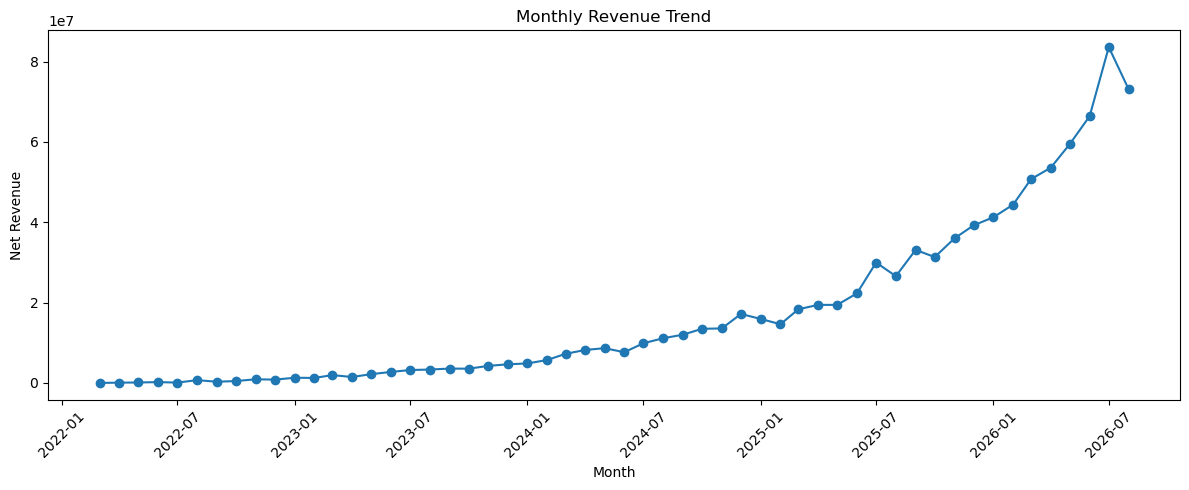

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"].dt.to_timestamp(),
    monthly_revenue["net_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
category_revenue = (
    orders_clean
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby("category")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue

,category,net_revenue
0,Electronics,6.562307e+08
1,Home & Kitchen,7.192793e+07
2,Fashion,6.214366e+07
3,Sports & Fitness,5.451120e+07
4,Beauty,4.691128e+07
5,Baby & Kids,2.879773e+07
6,Groceries,8.011512e+06
7,Books & Stationery,7.470744e+06


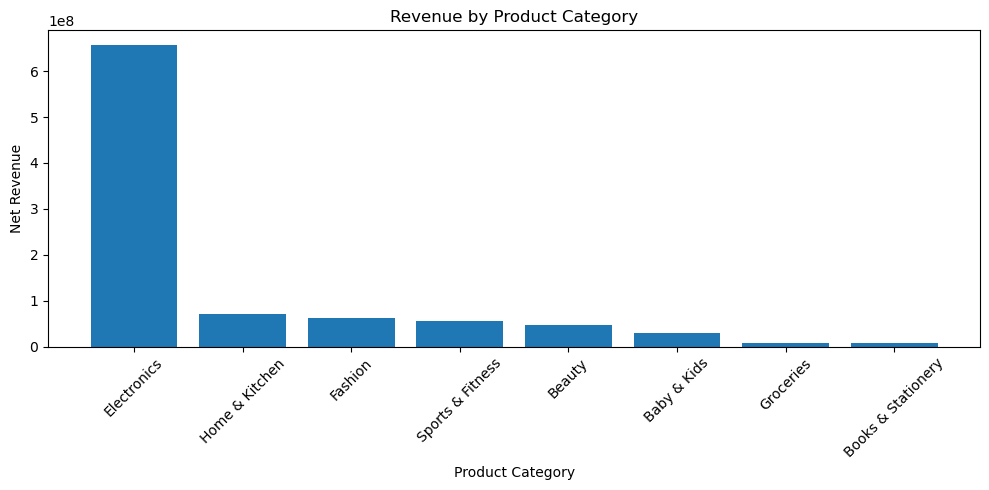

In [54]:
plt.figure(figsize=(10, 5))

plt.bar(
    category_revenue["category"],
    category_revenue["net_revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
city_revenue = (
    orders_clean
    .merge(
        customers[["customer_id", "city"]],
        on="customer_id",
        how="left"
    )
    .groupby("city")["net_revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

city_revenue

,city,net_revenue
0,Karachi,2.445868e+08
1,Lahore,1.722972e+08
2,Islamabad,8.972896e+07
3,Rawalpindi,8.153779e+07
4,Multan,6.227845e+07
5,Faisalabad,6.131414e+07
6,Peshawar,4.980836e+07
7,Hyderabad,3.785254e+07
8,Gujranwala,3.482031e+07
9,Sialkot,2.924215e+07


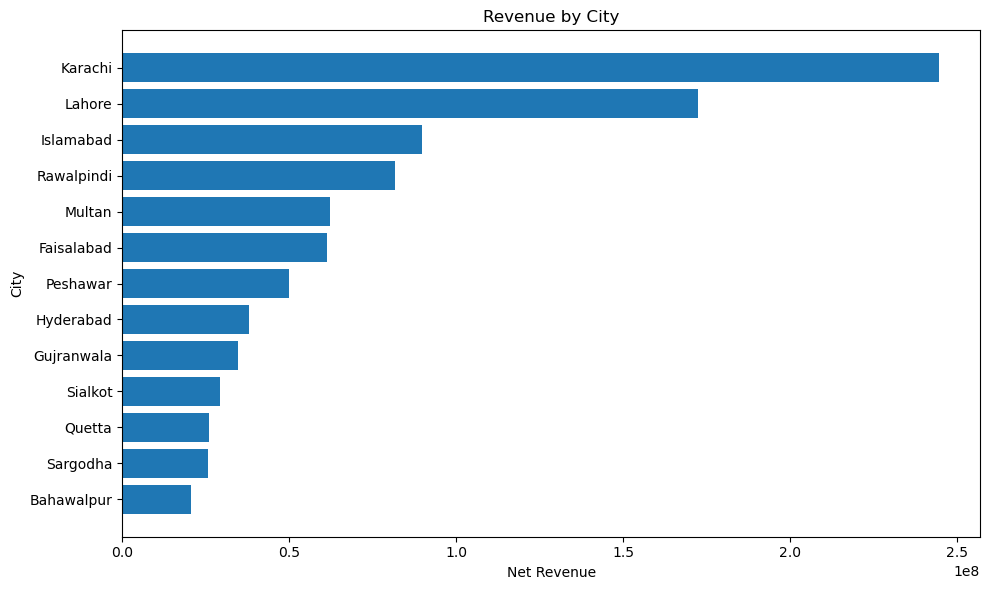

In [56]:
plt.figure(figsize=(10, 6))

plt.barh(
    city_revenue["city"],
    city_revenue["net_revenue"]
)

plt.title("Revenue by City")
plt.xlabel("Net Revenue")
plt.ylabel("City")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [57]:
orders_category = orders_clean.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

In [58]:
return_rate_category = (
    orders_category
    .groupby("category")["returned"]
    .mean()
    .mul(100)
    .reset_index(name="return_rate")
    .sort_values("return_rate", ascending=False)
)

return_rate_category

,category,return_rate
4,Fashion,11.253678
3,Electronics,7.983703
6,Home & Kitchen,6.588791
1,Beauty,5.801318
7,Sports & Fitness,5.790740
0,Baby & Kids,5.686065
5,Groceries,2.285808
2,Books & Stationery,2.092645


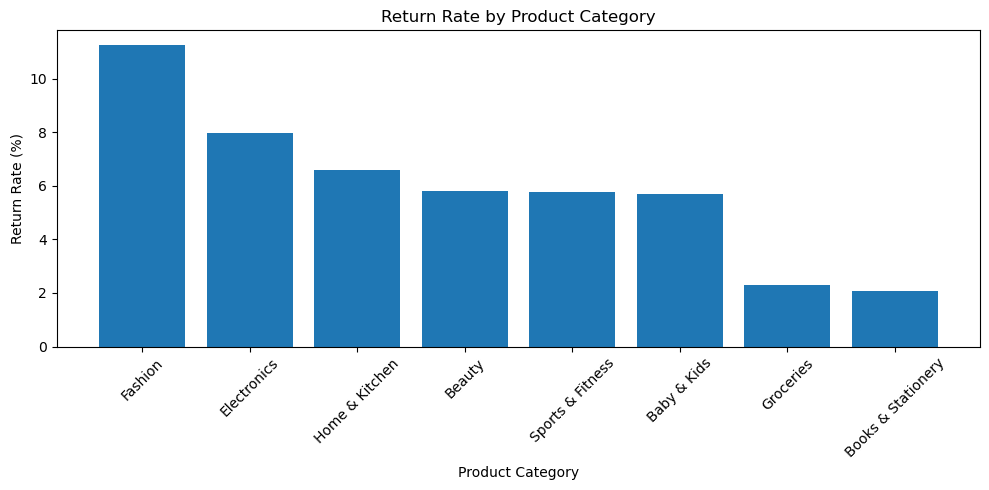

In [59]:
plt.figure(figsize=(10, 5))

plt.bar(
    return_rate_category["category"],
    return_rate_category["return_rate"]
)

plt.title("Return Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
print("Highest revenue category:")
print(category_revenue.iloc[0])

print("\nHighest revenue city:")
print(city_revenue.iloc[0])

print("\nHighest return-rate category:")
print(return_rate_category.iloc[0])

print("\nHighest revenue month:")
print(monthly_revenue.loc[
    monthly_revenue["net_revenue"].idxmax()
])

Highest revenue category:
category           Electronics
net_revenue    656230748.13767
Name: 0, dtype: object

Highest revenue city:
city                   Karachi
net_revenue    244586774.01661
Name: 0, dtype: object

Highest return-rate category:
category         Fashion
return_rate    11.253678
Name: 4, dtype: object

Highest revenue month:
month                 2026-07
net_revenue    83606363.19065
Name: 52, dtype: object


1. The highest-revenue category is ______.
   This matters because the business may depend heavily on this category
   for overall revenue, so inventory and availability in this category
   can have a material effect on sales.

2. The city with the highest revenue is ______.
   This matters because customer concentration in particular cities can
   help the business prioritize inventory, delivery capacity and marketing
   resources geographically.

3. The category with the highest return rate is ______.
   This matters because returns can create additional logistics and
   customer-service costs and may indicate a need to investigate product
   quality, expectations or product information.

In [ ]:
# **** ****

In [61]:
customers.columns.tolist()

['customer_id',
 'customer_name',
 'age',
 'gender',
 'city',
 'signup_date',
 'membership_type',
 'email',
 'phone']

In [62]:
feature_end = pd.Timestamp("2026-05-31")
target_start = pd.Timestamp("2026-06-01")
target_end = pd.Timestamp("2026-08-31")

In [63]:
feature_orders = orders_clean[
    orders_clean["order_date"] <= feature_end
].copy()

eligible_customers = feature_orders["customer_id"].unique()

print("Eligible customers:", len(eligible_customers))

Eligible customers: 6535


In [64]:
customer_features = (
    feature_orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique"),
        total_spending=("net_revenue", "sum"),
        average_order_value=("net_revenue", "mean"),
        last_order_date=("order_date", "max"),
        return_rate=("returned", "mean"),
        average_delivery_days=("delivery_days", "mean")
    )
    .reset_index()
)

In [65]:
customer_features["days_since_last_order"] = (
    feature_end - customer_features["last_order_date"]
).dt.days

In [66]:
customer_features = customer_features.drop(
    columns=["last_order_date"]
)

In [67]:
customer_features["return_rate"] = (
    customer_features["return_rate"] * 100
)

In [68]:
customer_features = customer_features.merge(
    customers[
        ["customer_id", "age", "membership_type"]
    ],
    on="customer_id",
    how="left"
)

In [69]:
customer_features.head()

,customer_id,total_orders,total_spending,average_order_value,return_rate,average_delivery_days,days_since_last_order,age,membership_type
0,2,3,6229.49896,2076.499653,0.0,4.666667,3,33.0,Silver
1,3,6,24102.46210,4017.077017,0.0,3.166667,107,25.0,Standard
2,4,5,14400.81290,2880.162580,0.0,3.000000,13,26.0,Standard
3,5,8,76312.80669,9539.100836,0.0,3.500000,19,27.0,Standard
4,6,3,50020.16297,16673.387657,0.0,3.000000,440,24.0,Standard


In [70]:
target_orders = orders_clean[
    (orders_clean["order_date"] >= target_start) &
    (orders_clean["order_date"] <= target_end)
].copy()

In [71]:
target_customers = set(
    target_orders["customer_id"]
)

In [72]:
customer_features["churn"] = (
    ~customer_features["customer_id"].isin(target_customers)
).astype(int)

In [74]:
customer_features["churn"].value_counts()

churn
0    3329
1    3206
Name: count, dtype: int64

In [75]:
customer_features["churn"].value_counts(normalize=True) * 100

churn
0    50.941086
1    49.058914
Name: proportion, dtype: float64

In [76]:
X = customer_features[
    [
        "total_orders",
        "total_spending",
        "average_order_value",
        "days_since_last_order",
        "return_rate",
        "average_delivery_days",
        "age",
        "membership_type"
    ]
]

y = customer_features["churn"]

In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [78]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = [
    "total_orders",
    "total_spending",
    "average_order_value",
    "days_since_last_order",
    "return_rate",
    "average_delivery_days",
    "age"
]

categorical_features = [
    "membership_type"
]

In [79]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [80]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [81]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [82]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [83]:
logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spending',
                                                   'average_order_value',
                                                   'days_since_last_order',
                                                   'return_rate',
                                                   'average_delivery_days',
                                                   'age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['membership_type'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [84]:
logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

In [85]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [86]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spending',
                                                   'average_order_value',
                                                   'days_since_last_order',
                                                   'return_rate',
                                                   'average_delivery_days',
                                                   'age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['membership_type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [87]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):

    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_true, y_pred, zero_division=0))
    print("ROC-AUC  :", roc_auc_score(y_true, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [89]:
evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

Logistic Regression
Accuracy : 0.7153787299158378
Precision: 0.6666666666666666
Recall   : 0.8393135725429017
F1-score : 0.7430939226519337
ROC-AUC  : 0.7871779736054308

Confusion Matrix:
[[397 269]
 [103 538]]
Random Forest
Accuracy : 0.6993114001530222
Precision: 0.6703296703296703
Recall   : 0.7613104524180967
F1-score : 0.7129291453615778
ROC-AUC  : 0.760159145104543

Confusion Matrix:
[[426 240]
 [153 488]]


In [90]:
ml_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

ml_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787178
1,Random Forest,0.699311,0.670330,0.761310,0.712929,0.760159


In [91]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [93]:
X_train_processed = (
    X_train_processed.toarray()
    if hasattr(X_train_processed, "toarray")
    else X_train_processed
)

X_test_processed = (
    X_test_processed.toarray()
    if hasattr(X_test_processed, "toarray")
    else X_test_processed
)

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

nn_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_processed.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

C:\anaconda\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [95]:
nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [96]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6399 - loss: 0.6230 - val_accuracy: 0.7151 - val_loss: 0.5561
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6856 - loss: 0.5669 - val_accuracy: 0.7180 - val_loss: 0.5452
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6923 - loss: 0.5583 - val_accuracy: 0.7237 - val_loss: 0.5417
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6963 - loss: 0.5555 - val_accuracy: 0.7208 - val_loss: 0.5420
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6982 - loss: 0.5525 - val_accuracy: 0.7208 - val_loss: 0.5410
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7016 - loss: 0.5509 - val_accuracy: 0.7161 - val_loss: 0.5409
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7016 - loss: 0.5492 - val_accuracy: 0.7161 - val_loss: 0.5410
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7001 - loss: 0.5480 - val_accuracy: 0.

In [97]:
nn_prob = nn_model.predict(
    X_test_processed
).ravel()

nn_pred = (nn_prob >= 0.5).astype(int)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [98]:
evaluate_model(
    "Neural Network",
    y_test,
    nn_pred,
    nn_prob
)

Neural Network
Accuracy : 0.7023718439173681
Precision: 0.6711956521739131
Recall   : 0.7706708268330733
F1-score : 0.7175018155410312
ROC-AUC  : 0.7801951717708348

Confusion Matrix:
[[424 242]
 [147 494]]


In [99]:
nn_results = pd.DataFrame({
    "Model": ["Neural Network"],
    "Accuracy": [accuracy_score(y_test, nn_pred)],
    "Precision": [precision_score(y_test, nn_pred, zero_division=0)],
    "Recall": [recall_score(y_test, nn_pred, zero_division=0)],
    "F1": [f1_score(y_test, nn_pred, zero_division=0)],
    "ROC-AUC": [roc_auc_score(y_test, nn_prob)]
})

all_model_results = pd.concat(
    [ml_results, nn_results],
    ignore_index=True
)

all_model_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787178
1,Random Forest,0.699311,0.670330,0.761310,0.712929,0.760159
2,Neural Network,0.702372,0.671196,0.770671,0.717502,0.780195


The neural network was compared with Logistic Regression and Random Forest on the same test set using the same churn features. The additional complexity of the neural network should be justified only if it provides a meaningful improvement in the relevant evaluation metrics; otherwise, the simpler model may be preferable because it is easier to interpret and deploy.

In [100]:
def sentiment_label(rating):

    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

In [101]:
reviews_clean["sentiment"] = reviews_clean["rating"].apply(
    sentiment_label
)

In [103]:
reviews_clean["sentiment"].value_counts()

sentiment
Positive    18453
Neutral      5462
Negative     2012
Name: count, dtype: int64

In [104]:
X_text = reviews_clean["review_text"].astype(str)
y_sentiment = reviews_clean["sentiment"]

In [105]:
from sklearn.model_selection import train_test_split

X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text,
    y_sentiment,
    test_size=0.20,
    random_state=42,
    stratify=y_sentiment
)

In [106]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_model = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2)
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

In [107]:
tfidf_model.fit(
    X_text_train,
    y_text_train
)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('model', LogisticRegression(max_iter=1000))])

In [108]:
sentiment_pred = tfidf_model.predict(
    X_text_test
)

In [109]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:",
      accuracy_score(y_text_test, sentiment_pred))

print("Precision:",
      precision_score(
          y_text_test,
          sentiment_pred,
          average="weighted",
          zero_division=0
      ))

print("Recall:",
      recall_score(
          y_text_test,
          sentiment_pred,
          average="weighted",
          zero_division=0
      ))

print("F1:",
      f1_score(
          y_text_test,
          sentiment_pred,
          average="weighted",
          zero_division=0
      ))

Accuracy: 0.9998071731585036
Precision: 0.9998072253867921
Recall: 0.9998071731585036
F1: 0.9998070661508179


The sentiment labels are inferred directly from star ratings rather than manually annotated text. This means a review with a rating of 3 is automatically treated as neutral even though the actual written language may contain positive or negative sentiment.

In [110]:
import os

os.makedirs("models", exist_ok=True)

In [117]:
import joblib

joblib.dump(logistic_model, "models/churn_model.pkl")

['models/churn_model.pkl']

In [112]:
joblib.dump(
    tfidf_model,
    "models/sentiment_model.pkl"
)

['models/sentiment_model.pkl']

In [113]:
nn_model.save(
    "models/churn_neural_network.keras"
)

In [114]:
customers.columns.tolist()

['customer_id',
 'customer_name',
 'age',
 'gender',
 'city',
 'signup_date',
 'membership_type',
 'email',
 'phone']

In [115]:
print(customers["membership_type"].value_counts(dropna=False))

membership_type
Standard    4629
Silver      1776
Gold        1113
Premium      482
Name: count, dtype: int64


In [116]:
display(all_model_results)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787178
1,Random Forest,0.699311,0.670330,0.761310,0.712929,0.760159
2,Neural Network,0.702372,0.671196,0.770671,0.717502,0.780195


In [118]:
import joblib

test_model = joblib.load("models/churn_model.pkl")

print(test_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_orders',
                                                   'total_spending',
                                                   'average_order_value',
                                                   'days_since_last_order',
                                                   'return_rate',
                                                   'average_delivery_days',
                                                   'age']),
                                                 ('cat',
                    

In [122]:
print("=== TOTAL REVENUE ===")
print(monthly_revenue)

print("\n=== TOP 5 PRODUCTS ===")
display(top_5_products)

print("\n=== CATEGORY REVENUE ===")
display(category_revenue)

print("\n=== CITY REVENUE ===")
display(city_revenue)

print("\n=== MONTHLY REVENUE ===")
display(monthly_revenue)

print("\n=== MODEL RESULTS ===")
display(all_model_results)

=== TOTAL REVENUE ===
      month   net_revenue
0   2022-03  8.425491e+03
1   2022-04  8.074637e+04
2   2022-05  1.197491e+05
3   2022-06  2.128555e+05
4   2022-07  9.148165e+04
5   2022-08  7.030608e+05
6   2022-09  3.074215e+05
7   2022-10  4.790411e+05
8   2022-11  9.171432e+05
9   2022-12  8.321830e+05
10  2023-01  1.297531e+06
11  2023-02  1.250409e+06
12  2023-03  1.956960e+06
13  2023-04  1.485384e+06
14  2023-05  2.195760e+06
15  2023-06  2.747246e+06
16  2023-07  3.216805e+06
17  2023-08  3.343571e+06
18  2023-09  3.581913e+06
19  2023-10  3.555609e+06
20  2023-11  4.258559e+06
21  2023-12  4.639214e+06
22  2024-01  4.866609e+06
23  2024-02  5.709370e+06
24  2024-03  7.265012e+06
25  2024-04  8.218981e+06
26  2024-05  8.663582e+06
27  2024-06  7.653615e+06
28  2024-07  9.890518e+06
29  2024-08  1.113249e+07
30  2024-09  1.201366e+07
31  2024-10  1.348597e+07
32  2024-11  1.357636e+07
33  2024-12  1.717773e+07
34  2025-01  1.593979e+07
35  2025-02  1.461741e+07
36  2025-03  1.8

,product_name,category,net_revenue
0,Samsung Headphones Classic,Electronics,1.172015e+08
1,Anker Headphones Classic,Electronics,7.123627e+07
2,Dawlance LED TV Premium,Electronics,2.077304e+07
3,Infinix LED TV 2026,Electronics,1.627931e+07
4,Dawlance Router Eco,Electronics,1.513557e+07



=== CATEGORY REVENUE ===


,category,net_revenue
0,Electronics,6.562307e+08
1,Home & Kitchen,7.192793e+07
2,Fashion,6.214366e+07
3,Sports & Fitness,5.451120e+07
4,Beauty,4.691128e+07
5,Baby & Kids,2.879773e+07
6,Groceries,8.011512e+06
7,Books & Stationery,7.470744e+06



=== CITY REVENUE ===


,city,net_revenue
0,Karachi,2.445868e+08
1,Lahore,1.722972e+08
2,Islamabad,8.972896e+07
3,Rawalpindi,8.153779e+07
4,Multan,6.227845e+07
5,Faisalabad,6.131414e+07
6,Peshawar,4.980836e+07
7,Hyderabad,3.785254e+07
8,Gujranwala,3.482031e+07
9,Sialkot,2.924215e+07



=== MONTHLY REVENUE ===


,month,net_revenue
0,2022-03,8.425491e+03
1,2022-04,8.074637e+04
2,2022-05,1.197491e+05
3,2022-06,2.128555e+05
4,2022-07,9.148165e+04
5,2022-08,7.030608e+05
6,2022-09,3.074215e+05
7,2022-10,4.790411e+05
8,2022-11,9.171432e+05
9,2022-12,8.321830e+05



=== MODEL RESULTS ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.715379,0.666667,0.839314,0.743094,0.787178
1,Random Forest,0.699311,0.670330,0.761310,0.712929,0.760159
2,Neural Network,0.702372,0.671196,0.770671,0.717502,0.780195


In [ ]:
###

In [ ]:
###

In [ ]:
###

In [ ]:
###

In [ ]:
###

In [ ]:
###

In [ ]:
###